In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\ensemble\weight_boosting.py:29: DeprecationWarning: numpy.core.umath_tests is an internal NumPy module and should not be imported. It will be removed in a future NumPy release.
  from numpy.core.umath_tests import inner1d


In [4]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [5]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
print(df.shape)

(545, 13)


In [7]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
price               545 non-null int64
area                545 non-null int64
bedrooms            545 non-null int64
bathrooms           545 non-null int64
stories             545 non-null int64
mainroad            545 non-null object
guestroom           545 non-null object
basement            545 non-null object
hotwaterheating     545 non-null object
airconditioning     545 non-null object
parking             545 non-null int64
prefarea            545 non-null object
furnishingstatus    545 non-null object
dtypes: int64(6), object(7)
memory usage: 55.4+ KB


In [9]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [12]:
df.drop_duplicates(inplace=True)

In [15]:
cat_cols = df.select_dtypes(include="object").columns

In [16]:
cat_cols

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [17]:
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

In [18]:
X = df.drop("price", axis=1)
y = df["price"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42
)

In [20]:
lr = LinearRegression()

In [21]:
lr.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

In [22]:
lr_pred = lr.predict(X_test)

In [23]:
print("MAE:",mean_absolute_error(y_test, lr_pred))

MAE: 970043.403920164


In [24]:
print("RMSE:",np.sqrt(mean_squared_error(y_test,lr_pred)))

RMSE: 1324506.9600914388


In [26]:
print("R square:",r2_score(y_test,lr_pred))

R square: 0.6529242642153184


In [27]:
rf = RandomForestRegressor(random_state=42)

In [29]:
rf.fit(X_train,y_train)

RandomForestRegressor(bootstrap=True, criterion='mse', max_depth=None,
           max_features='auto', max_leaf_nodes=None,
           min_impurity_decrease=0.0, min_impurity_split=None,
           min_samples_leaf=1, min_samples_split=2,
           min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=1,
           oob_score=False, random_state=42, verbose=0, warm_start=False)

In [30]:
rf_pred = rf.predict(X_test)

In [31]:
print("MAE:",mean_absolute_error(y_test,rf_pred))

MAE: 1021184.7247706422


In [32]:
print("RMSE:",np.sqrt(mean_squared_error(y_test,rf_pred)))

RMSE: 1365449.501461856


In [33]:
print("R2:",r2_score(y_test,rf_pred))

R2: 0.6311353388776826


In [34]:
#Comparison Table

In [35]:
results = pd.DataFrame({"Model": ["Linear Regression","Random Forest"],
                        "R2 Score": [r2_score(y_test,lr_pred),r2_score(y_test,rf_pred)]})
                                     
                                
                                     

In [36]:
results

,Model,R2 Score
0,Linear Regression,0.652924
1,Random Forest,0.631135


In [37]:
#Charts:

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["price"],
    bins=30
)
plt.title("Price Distribution")
plt.show()

AttributeError: module 'seaborn' has no attribute 'histplot'

<Figure size 576x360 with 0 Axes>

In [39]:
import seaborn as sns
print(sns.__version__)

0.9.0


In [47]:
#chart1

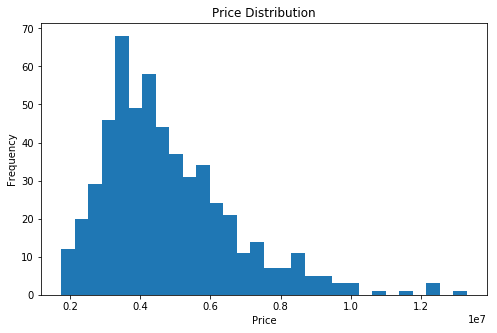

In [41]:
plt.figure(figsize=(8,5))
plt.hist(df["price"],bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [48]:
#Most houses are concentrated within a particular price range, while a few houses have very high prices.

In [42]:
#chart2

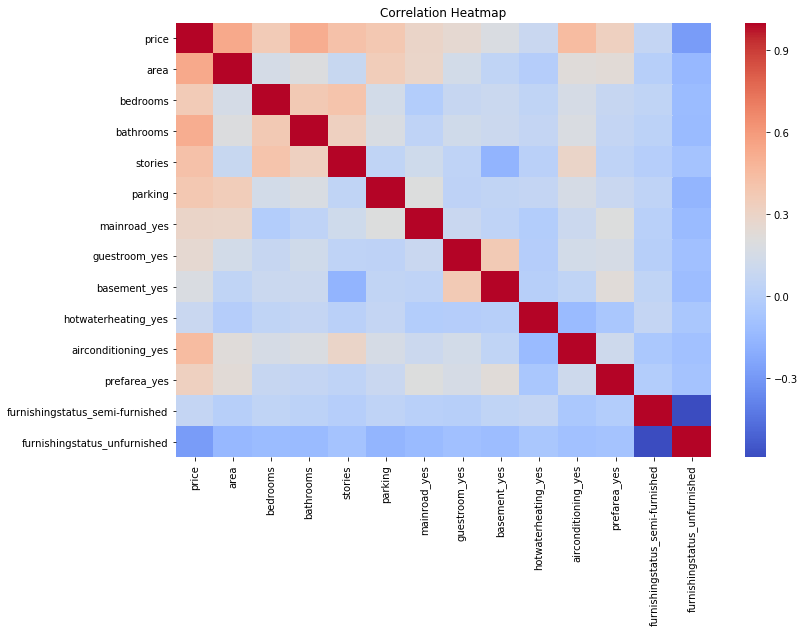

In [43]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [49]:
#Features with stronger positive correlations are more likely to influence house prices.

In [44]:
#chart3

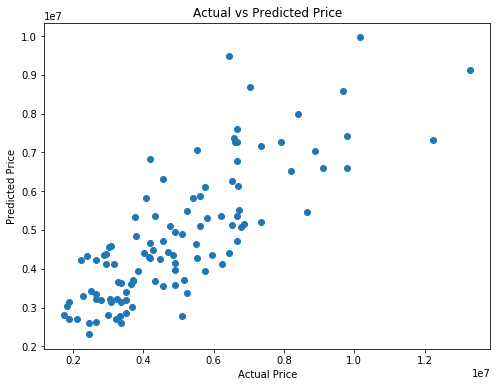

In [46]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [50]:
#Most points are close to the expected trend, indicating that the model is able to predict house prices reasonably well.